In [1]:
# Célula 1: Importações e configurações
"""
Módulo de Teste: Avaliação dos modelos CNN treinados
Entrada: Modelos salvos e pastas com imagens de teste
Saída: Previsões e métricas de desempenho
"""
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
import timm
import pickle
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from config import *

# Configurações adicionais para teste
TEST_IMAGES_DIR = 'dataset/cnmc2019_splits/images/test' # Pasta principal contendo as subpastas ALL e HEM
RESULTS_DIR = 'test_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

/mnt/c/Mestrado/artigo_cnn_eficiente/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def diagnose_checkpoint(checkpoint_path):
    """Diagnóstica o formato do checkpoint salvo"""
    print(f"\nDiagnosticando: {checkpoint_path}")
    
    try:
        # Carregar com diferentes configurações
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        
        # Verificar o tipo
        print(f"Tipo do checkpoint: {type(checkpoint)}")
        
        if isinstance(checkpoint, dict):
            print("Chaves encontradas:", list(checkpoint.keys()))
            for key, value in checkpoint.items():
                if isinstance(value, torch.Tensor):
                    print(f"  {key}: Tensor com shape {value.shape}")
                else:
                    print(f"  {key}: {type(value)}")
        elif isinstance(checkpoint, torch.nn.Module):
            print("Checkpoint é um modelo direto (não um dict)")
            return 'direct_model'
        elif hasattr(checkpoint, 'state_dict'):
            print("Checkpoint tem state_dict")
            return 'model_object'
        else:
            print(f"Formato desconhecido: {type(checkpoint)}")
            
    except Exception as e:
        print(f"Erro ao carregar checkpoint: {e}")
        return None
    
    return checkpoint

# Use esta função antes de carregar o modelo
checkpoint_format = diagnose_checkpoint('models/modular/tf_efficientnetv2_b3_best.pt')


Diagnosticando: models/modular/tf_efficientnetv2_b3_best.pt
Tipo do checkpoint: <class 'dict'>
Chaves encontradas: ['model_state_dict', 'optimizer_state_dict', 'epoch', 'best_f1', 'val_f1', 'train_f1', 'gap', 'val_loss']
  model_state_dict: <class 'collections.OrderedDict'>
  optimizer_state_dict: <class 'dict'>
  epoch: <class 'int'>
  best_f1: <class 'float'>
  val_f1: <class 'float'>
  train_f1: <class 'float'>
  gap: <class 'float'>
  val_loss: <class 'float'>


In [3]:
import torch
import os
import numpy as np
from collections import defaultdict

def comprehensive_diagnosis():
    """Diagnóstico completo do problema"""
    
    print("="*60)
    print("DIAGNÓSTICO COMPLETO DO MODELO")
    print("="*60)
    
    # 1. Verificar o checkpoint salvo
    checkpoint_path = 'models/modular/tf_efficientnetv2_b3_best.pt'
    
    if not os.path.exists(checkpoint_path):
        print(f"❌ Checkpoint não encontrado: {checkpoint_path}")
        return
    
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    
    print("\n📦 Conteúdo do Checkpoint:")
    for key, value in checkpoint.items():
        if isinstance(value, dict):
            print(f"  {key}: dict com {len(value)} chaves")
        elif isinstance(value, torch.Tensor):
            print(f"  {key}: tensor {value.shape}")
        else:
            print(f"  {key}: {value}")
    
    # 2. Verificar métricas salvas
    if 'val_f1' in checkpoint:
        print(f"\n📊 Métricas no checkpoint:")
        print(f"  Val F1: {checkpoint['val_f1']:.4f}")
        print(f"  Train F1: {checkpoint.get('train_f1', 'N/A')}")
        print(f"  Gap: {checkpoint.get('gap', 'N/A')}")
        print(f"  Best F1: {checkpoint.get('best_f1', 'N/A')}")
    
    # 3. Analisar distribuição de dados
    print("\n📁 Análise de Dados:")
    
    def analyze_dataset(path, name):
        all_patients = defaultdict(list)
        
        for class_name in ['ALL', 'all', 'HEM', 'hem']:
            class_path = os.path.join(path, class_name)
            if os.path.exists(class_path):
                print(f"\n  {name}/{class_name}:")
                for img in os.listdir(class_path):
                    if img.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        # Extrair patient_id
                        parts = img.split('_')
                        if len(parts) >= 2:
                            patient_id = parts[1]
                            all_patients[patient_id].append((class_name.upper(), img))
                
                print(f"    Total de imagens: {len(os.listdir(class_path))}")
        
        return all_patients
    
    # Analisar cada conjunto
    train_patients = analyze_dataset('dataset/cnmc2019_splits/images/train', 'Train')
    val_patients = analyze_dataset('dataset/cnmc2019_splits/images/val', 'Val')
    test_patients = analyze_dataset('dataset/cnmc2019_splits/images/test', 'Test')
    
    # 4. Verificar sobreposição de pacientes
    print("\n🔍 Verificação de Data Leakage:")
    
    train_ids = set(train_patients.keys())
    val_ids = set(val_patients.keys())
    test_ids = set(test_patients.keys())
    
    overlap_train_val = train_ids.intersection(val_ids)
    overlap_train_test = train_ids.intersection(test_ids)
    overlap_val_test = val_ids.intersection(test_ids)
    
    print(f"  Pacientes em treino: {len(train_ids)}")
    print(f"  Pacientes em validação: {len(val_ids)}")
    print(f"  Pacientes em teste: {len(test_ids)}")
    print(f"  Sobreposição treino-val: {len(overlap_train_val)}")
    print(f"  Sobreposição treino-teste: {len(overlap_train_test)}")
    print(f"  Sobreposição val-teste: {len(overlap_val_test)}")
    
    if overlap_train_test:
        print(f"  ⚠️ ALERTA: Pacientes em treino E teste: {list(overlap_train_test)[:5]}")
    
    return checkpoint, train_patients, val_patients, test_patients

# Executar diagnóstico
diagnosis_results = comprehensive_diagnosis()

DIAGNÓSTICO COMPLETO DO MODELO

📦 Conteúdo do Checkpoint:
  model_state_dict: dict com 644 chaves
  optimizer_state_dict: dict com 2 chaves
  epoch: 48
  best_f1: 0.972683983759413
  val_f1: 0.972683983759413
  train_f1: 0.991892439372424
  gap: 0.01920845561301099
  val_loss: 0.012538342758321688

📊 Métricas no checkpoint:
  Val F1: 0.9727
  Train F1: 0.991892439372424
  Gap: 0.01920845561301099
  Best F1: 0.972683983759413

📁 Análise de Dados:

  Train/ALL:
    Total de imagens: 5335

  Train/all:
    Total de imagens: 5335

  Train/HEM:
    Total de imagens: 5767

  Train/hem:
    Total de imagens: 5767

  Val/ALL:
    Total de imagens: 571

  Val/all:
    Total de imagens: 571

  Val/HEM:
    Total de imagens: 601

  Val/hem:
    Total de imagens: 601

  Test/ALL:
    Total de imagens: 124

  Test/all:
    Total de imagens: 124

  Test/HEM:
    Total de imagens: 90

  Test/hem:
    Total de imagens: 90

🔍 Verificação de Data Leakage:
  Pacientes em treino: 49
  Pacientes em validaç

In [4]:
import torch
from collections import OrderedDict

# Carrega o checkpoint do caminho correto
ckpt = torch.load("models/modular/tf_efficientnetv2_b3_best.pt", map_location="cpu")

# Se foi salvo como {"model_state_dict": ..., ...}, pega só os pesos
state = ckpt.get("model_state_dict", ckpt)

# Remove prefixo "module." se o modelo foi treinado com DataParallel
if any(k.startswith("module.") for k in state.keys()):
    new_state = OrderedDict((k.replace("module.", "", 1), v) for k, v in state.items())
    state = new_state

print("✅ Checkpoint carregado com sucesso!")
print("Exemplo de chaves do state_dict:", list(state.keys())[:10])



✅ Checkpoint carregado com sucesso!
Exemplo de chaves do state_dict: ['backbone.conv_stem.weight', 'backbone.bn1.weight', 'backbone.bn1.bias', 'backbone.bn1.running_mean', 'backbone.bn1.running_var', 'backbone.bn1.num_batches_tracked', 'backbone.blocks.0.0.conv.weight', 'backbone.blocks.0.0.bn1.weight', 'backbone.blocks.0.0.bn1.bias', 'backbone.blocks.0.0.bn1.running_mean']


In [5]:
# Configurações otimizadas para melhor performance
BATCH_SIZE = 16   # Reduzir batch size para imagens maiores
NUM_WORKERS = 4

# Test Time Augmentation (TTA)
def get_tta_transforms():
    """Transformações para Test Time Augmentation"""
    return [
        transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomVerticalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
    ]

def predict_with_tta(model, image_path):
    """Predição com Test Time Augmentation"""
    tta_transforms = get_tta_transforms()
    image = Image.open(image_path).convert('RGB')
    
    predictions = []
    for transform in tta_transforms:
        img_tensor = transform(image).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(img_tensor)
            prob = F.softmax(output, dim=1)
            predictions.append(prob.cpu().numpy())
    
    # Média das predições
    avg_prediction = np.mean(predictions, axis=0)
    return avg_prediction[0]

In [6]:
# Célula 2: Dataset para carregar imagens das pastas
class FolderLeukemiaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.image_paths = []
        
        # Mapear classes - verificar maiúsculas e minúsculas
        class_dirs = ['HEM', 'hem', 'ALL', 'all']
        class_mapping = {}
        
        for class_name in class_dirs:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.exists(class_dir):
                # Normalizar para uppercase
                normalized_name = class_name.upper()
                if normalized_name == 'HEM':
                    class_mapping[class_dir] = (0, 'HEM')
                elif normalized_name == 'ALL':
                    class_mapping[class_dir] = (1, 'ALL')
        
        if len(class_mapping) == 0:
            raise ValueError(f"Nenhuma pasta de classe encontrada em {root_dir}")
        
        # Carregar imagens de cada classe
        for class_dir, (class_label, class_name) in class_mapping.items():
            img_count = 0
            
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    img_path = os.path.join(class_dir, img_name)
                    
                    # Verificar se arquivo existe e não está corrompido
                    if os.path.isfile(img_path) and os.path.getsize(img_path) > 0:
                        self.image_paths.append(img_path)
                        self.labels.append(class_label)
                        
                        # Extrair ID do paciente
                        patient_id = self._extract_patient_id(img_name)
                        
                        self.images.append({
                            'path': img_path,
                            'label': class_label,
                            'patient_id': patient_id,
                            'filename': img_name,
                            'class_name': class_name
                        })
                        img_count += 1
            
            print(f"  {class_name}: {img_count} imagens carregadas de {class_dir}")
        
        if len(self.images) == 0:
            raise ValueError("Nenhuma imagem válida encontrada!")
            
        print(f"\nDataset de teste carregado com sucesso:")
        print(f"  Total de imagens: {len(self.images)}")
        print(f"  Distribuição de classes:")
        print(f"    ALL (classe 1): {sum(1 for item in self.images if item['label'] == 1)}")
        print(f"    HEM (classe 0): {sum(1 for item in self.images if item['label'] == 0)}")
    
    def _extract_patient_id(self, img_name):
        """Extrai ID do paciente do nome do arquivo"""
        try:
            # Formato esperado: UID_PATIENTID_CELLNUMBER.ext
            parts = img_name.split('_')
            if len(parts) >= 2:
                return parts[1]
            else:
                # Fallback: usar nome sem extensão
                return os.path.splitext(img_name)[0]
        except:
            return os.path.splitext(img_name)[0]
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_info = self.images[idx]
        
        try:
            image = Image.open(img_info['path']).convert('RGB')
        except Exception as e:
            print(f"Erro ao carregar {img_info['path']}: {e}")
            # Criar imagem preta como fallback
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color='black')
        
        if self.transform:
            image = self.transform(image)
        
        return image, img_info['label'], img_info['patient_id'], img_info['filename']


In [7]:
# Célula 3: Reconstruir o modelo CNN (mesma arquitetura do treinamento)
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class CNNModel(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,  # ← pode ser False para eval
            num_classes=0,
            global_pool='',  # ← sem global_pool aqui
            drop_rate=0.3,
            drop_path_rate=0.2
        )
        
        num_features = self.backbone.num_features
        
        # Adicionar SE Attention ANTES do pooling
        self.attention = SEBlock(num_features, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Mesma arquitetura do classificador do treinamento
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),  # ← ReLU ao invés de GELU
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),  # ← ReLU ao invés de GELU
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # Extrair features do backbone
        features = self.backbone(x)
        # Aplicar SE attention
        features = self.attention(features)
        # Global pooling
        features = self.global_pool(features).flatten(1)
        # Classificador
        return self.classifier(features)

In [8]:
# Célula 4: Funções para carregar modelos e fazer previsões
def load_trained_model(model_name, checkpoint_path):
    """Carrega um modelo treinado do checkpoint"""
    model = CNNModel(model_name, NUM_CLASSES)
    
    if os.path.exists(checkpoint_path):
        # Adicionar tratamento para weights_only e map_location
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        
        # Verificar se é um dict válido antes de acessar
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            best_f1 = checkpoint.get('best_f1', 0.0)
            print(f"✅ Modelo {model_name} carregado - Best F1: {best_f1:.4f}")
            
            # Verificar se o SEBlock foi carregado corretamente
            if hasattr(model, 'attention'):
                print(f"  ✓ SEBlock carregado corretamente")
            else:
                print(f"  ⚠️ SEBlock não encontrado no modelo")
                
        else:
            print(f"⚠️ Formato inválido do checkpoint: {checkpoint_path}")
            return None
    else:
        print(f"⚠️ Checkpoint não encontrado: {checkpoint_path}")
        return None
    
    model = model.to(DEVICE)
    model.eval()
    return model

def predict_with_model(model, dataloader, return_probs=True):
    """Faz previsões usando um modelo com validação robusta"""
    if model is None:
        print("⚠️ Modelo é None")
        return None
        
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    all_patient_ids = []
    all_image_names = []
    
    with torch.no_grad():
        for batch_data in tqdm(dataloader, desc='Predicting'):
            # Validar número de elementos no batch
            if len(batch_data) != 4:
                print(f"⚠️ Batch com formato incorreto: {len(batch_data)} elementos")
                continue
                
            images, labels, patient_ids, image_names = batch_data
            
            # Validar tipos
            if not isinstance(images, torch.Tensor):
                print("⚠️ Images não é tensor")
                continue
                
            images = images.to(DEVICE)
            
            try:
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.numpy() if isinstance(labels, torch.Tensor) else labels)
                all_patient_ids.extend(patient_ids)
                all_image_names.extend(image_names)
                
            except Exception as e:
                print(f"⚠️ Erro na predição do batch: {e}")
                continue
    
    if len(all_preds) == 0:
        print("⚠️ Nenhuma predição realizada")
        return None
        
    if return_probs:
        return all_preds, all_probs, all_labels, all_patient_ids, all_image_names
    return all_preds, all_labels, all_patient_ids, all_image_names

# Célula 5: Função para calcular métricas
def calculate_metrics(y_true, y_pred, y_probs=None, model_name="Model"):
    """Calcula e exibe métricas de avaliação"""       

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Validar dados
    if len(y_true) == 0 or len(y_pred) == 0:
        print(f"⚠️ Dados vazios para {model_name}")
        return None
    
    # Métricas básicas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Métricas por classe com tratamento para classes ausentes
    unique_classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(unique_classes)
    
    if n_classes >= 2:
        precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
        recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
        f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    else:
        precision_per_class = [precision]
        recall_per_class = [recall]
        f1_per_class = [f1]

    # Métricas básicas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # Métricas por classe
    precision_per_class = precision_score(y_true, y_pred, average=None)
    recall_per_class = recall_score(y_true, y_pred, average=None)
    f1_per_class = f1_score(y_true, y_pred, average=None)
    
    print(f"\n{'='*50}")
    print(f"MÉTRICAS - {model_name}")
    print('='*50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print("\nMétricas por Classe:")
    print(f"  HEM (0) - Precision: {precision_per_class[0]:.4f}, Recall: {recall_per_class[0]:.4f}, F1: {f1_per_class[0]:.4f}")
    print(f"  ALL (1) - Precision: {precision_per_class[1]:.4f}, Recall: {recall_per_class[1]:.4f}, F1: {f1_per_class[1]:.4f}")
    
    # AUC-ROC com validação
    auc = None
    if y_probs is not None:
        try:
            y_probs_array = np.array(y_probs)
            if y_probs_array.ndim == 2 and y_probs_array.shape[1] >= 2:
                y_probs_class1 = y_probs_array[:, 1]
                if len(np.unique(y_true)) >= 2:
                    auc = roc_auc_score(y_true, y_probs_class1)
                    print(f"AUC-ROC:   {auc:.4f}")
        except Exception as e:
            print(f"⚠️ Erro ao calcular AUC: {e}")
    else:
        auc = None
    
    # Relatório de classificação
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=['HEM', 'ALL']))
    
    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }
    
    return metrics


In [9]:
# Célula 6: Função para visualizar resultados
def plot_confusion_matrix(cm, title="Confusion Matrix", save_path=None):
    """Plota matriz de confusão"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['HEM', 'ALL'], 
                yticklabels=['HEM', 'ALL'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

def plot_roc_curve(y_true, y_probs, title="ROC Curve", save_path=None):
    """Plota curva ROC"""
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auc = roc_auc_score(y_true, y_probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

In [10]:
# Célula 7: Testar modelos individuais
def test_single_model(model_name, test_images_dir=TEST_IMAGES_DIR):
    """Testa um único modelo CNN"""
    print(f"\n{'='*60}")
    print(f"Testando modelo: {model_name}")
    print('='*60)
    
    # Preparar dataset de teste
    test_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_dataset = FolderLeukemiaDataset(test_images_dir, test_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    
    # Carregar modelo
    model_filename = f'{model_name.replace("/", "_")}_best.pt'
    checkpoint_path = os.path.join(SAVE_DIR, model_filename)    
    
    model = load_trained_model(model_name, checkpoint_path)
    if model is None:
        return None
    
    # Fazer previsões
    preds, probs, labels, patient_ids, image_names = predict_with_model(model, test_loader)
    
    # Calcular métricas
    metrics = calculate_metrics(labels, preds, probs, model_name)
    
    # Visualizações
    plot_confusion_matrix(
        metrics['confusion_matrix'], 
        title=f"Confusion Matrix - {model_name}",
        save_path=os.path.join(RESULTS_DIR, f'{model_name.replace("/", "_")}_cm.png')
    )
    
    if metrics['auc'] is not None:
        y_probs_class1 = [p[1] for p in probs]
        plot_roc_curve(
            labels, y_probs_class1,
            title=f"ROC Curve - {model_name}",
            save_path=os.path.join(RESULTS_DIR, f'{model_name.replace("/", "_")}_roc.png')
        )
    
    # Salvar previsões detalhadas
    results_df = pd.DataFrame({
        'Patient_ID': patient_ids,
        'nome_imagem': image_names,
        'classe_real': labels,
        'classe_predita': preds,
        'prob_HEM': [p[0] for p in probs],
        'prob_ALL': [p[1] for p in probs]
    })
    
    results_df.to_csv(
        os.path.join(RESULTS_DIR, f'{model_name.replace("/", "_")}_predictions.csv'),
        index=False
    )
    
    return metrics

In [11]:
# Célula 8: Ensemble de modelos
def ensemble_predictions(models_predictions, method='voting'):
    """
    Combina previsões de múltiplos modelos
    
    Args:
        models_predictions: Lista de tuplas (preds, probs) de cada modelo
        method: 'voting' para votação majoritária, 'average' para média de probabilidades
    """
    if method == 'voting':
        # Votação majoritária
        all_preds = np.array([preds for preds, _ in models_predictions])
        ensemble_preds = np.apply_along_axis(
            lambda x: np.bincount(x).argmax(), 
            axis=0, 
            arr=all_preds
        )
        return ensemble_preds
    
    elif method == 'average':
        # Média das probabilidades
        all_probs = np.array([probs for _, probs in models_predictions])
        avg_probs = np.mean(all_probs, axis=0)
        ensemble_preds = np.argmax(avg_probs, axis=1)
        return ensemble_preds, avg_probs
    
    else:
        raise ValueError(f"Método desconhecido: {method}")


In [12]:

# Célula 9: Testar ensemble de modelos
def test_ensemble(test_images_dir=TEST_IMAGES_DIR):
    """Testa ensemble de todos os modelos disponíveis"""
    print("\n" + "="*60)
    print("TESTANDO ENSEMBLE DE MODELOS")
    print("="*60)
    
    # Preparar dataset
    test_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_dataset = FolderLeukemiaDataset(test_images_dir, test_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    
    # Coletar previsões de todos os modelos
    all_models_predictions = []
    all_models_names = []
    labels = None
    patient_ids = None
    image_names = None
    
    for model_name in CNN_MODELS:
        model_filename = f'{model_name.replace("/", "_")}_best.pt'
        checkpoint_path = os.path.join(SAVE_DIR, model_filename)
        
        if os.path.exists(checkpoint_path):
            print(f"\nCarregando {model_name}...")
            model = load_trained_model(model_name, checkpoint_path)
            
            if model is not None:
                preds, probs, curr_labels, curr_patient_ids, curr_image_names = predict_with_model(model, test_loader)
                all_models_predictions.append((preds, probs))
                all_models_names.append(model_name)
                
                if labels is None:
                    labels = curr_labels
                    patient_ids = curr_patient_ids
                    image_names = curr_image_names
                
                # Limpar memória
                del model
                torch.cuda.empty_cache()
    
    if len(all_models_predictions) == 0:
        print("❌ Nenhum modelo encontrado para ensemble!")
        return
    
    print(f"\n✅ Ensemble com {len(all_models_predictions)} modelos")
    
    # Ensemble por votação
    print("\n--- Ensemble por Votação ---")
    ensemble_preds_voting = ensemble_predictions(all_models_predictions, method='voting')
    metrics_voting = calculate_metrics(labels, ensemble_preds_voting, None, "Ensemble (Voting)")
    
    # Ensemble por média de probabilidades
    print("\n--- Ensemble por Média de Probabilidades ---")
    ensemble_preds_avg, ensemble_probs_avg = ensemble_predictions(all_models_predictions, method='average')
    metrics_avg = calculate_metrics(labels, ensemble_preds_avg, ensemble_probs_avg, "Ensemble (Average)")
    
    # Visualizações para ensemble
    plot_confusion_matrix(
        metrics_avg['confusion_matrix'],
        title="Confusion Matrix - Ensemble (Average)",
        save_path=os.path.join(RESULTS_DIR, 'ensemble_cm.png')
    )
    
    if ensemble_probs_avg is not None:
        y_probs_class1 = [p[1] for p in ensemble_probs_avg]
        plot_roc_curve(
            labels, y_probs_class1,
            title="ROC Curve - Ensemble",
            save_path=os.path.join(RESULTS_DIR, 'ensemble_roc.png')
        )
    
    # Salvar previsões do ensemble
    results_df = pd.DataFrame({
        'Patient_ID': patient_ids,
        'nome_imagem': image_names,
        'classe_real': labels,
        'classe_predita_voting': ensemble_preds_voting,
        'classe_predita_avg': ensemble_preds_avg,
        'prob_HEM': [p[0] for p in ensemble_probs_avg],
        'prob_ALL': [p[1] for p in ensemble_probs_avg]
    })
    
    results_df.to_csv(os.path.join(RESULTS_DIR, 'ensemble_predictions.csv'), index=False)
    
    return {
        'voting': metrics_voting,
        'average': metrics_avg,
        'models_used': all_models_names
    }

In [13]:
# Célula 10: Análise de erros
def analyze_errors(csv_path='ensemble_predictions.csv'):
    """Analisa os erros de classificação"""
    df = pd.read_csv(os.path.join(RESULTS_DIR, csv_path))
    
    # Identificar erros
    df['erro'] = df['classe_real'] != df['classe_predita_avg']
    errors_df = df[df['erro']].copy()
    
    print("\n" + "="*60)
    print("ANÁLISE DE ERROS")
    print("="*60)
    print(f"Total de erros: {len(errors_df)} / {len(df)} ({len(errors_df)/len(df)*100:.2f}%)")
    
    # Erros por classe
    print("\nErros por classe real:")
    print(f"  HEM incorretamente classificado como ALL: {((errors_df['classe_real'] == 0) & (errors_df['classe_predita_avg'] == 1)).sum()}")
    print(f"  ALL incorretamente classificado como HEM: {((errors_df['classe_real'] == 1) & (errors_df['classe_predita_avg'] == 0)).sum()}")
    
    # Casos com baixa confiança
    df['confianca'] = df[['prob_HEM', 'prob_ALL']].max(axis=1)
    baixa_confianca = df[df['confianca'] < 0.7]
    
    print(f"\nCasos com baixa confiança (<70%): {len(baixa_confianca)} ({len(baixa_confianca)/len(df)*100:.2f}%)")
    
    # Distribuição de confiança
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.hist(df['confianca'], bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('Confiança')
    plt.ylabel('Frequência')
    plt.title('Distribuição de Confiança nas Previsões')
    
    plt.subplot(1, 3, 2)
    correct_conf = df[~df['erro']]['confianca']
    wrong_conf = df[df['erro']]['confianca']
    plt.hist([correct_conf, wrong_conf], bins=15, label=['Correto', 'Erro'], alpha=0.7)
    plt.xlabel('Confiança')
    plt.ylabel('Frequência')
    plt.title('Confiança: Acertos vs Erros')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    # Box plot por classe
    data_to_plot = [
        df[df['classe_real'] == 0]['confianca'],
        df[df['classe_real'] == 1]['confianca']
    ]
    plt.boxplot(data_to_plot, labels=['HEM', 'ALL'])
    plt.ylabel('Confiança')
    plt.title('Confiança por Classe Real')
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'confidence_analysis.png'), dpi=100)
    plt.show()
    
    # Salvar casos difíceis para análise
    errors_df.to_csv(os.path.join(RESULTS_DIR, 'error_cases.csv'), index=False)
    baixa_confianca.to_csv(os.path.join(RESULTS_DIR, 'low_confidence_cases.csv'), index=False)
    
    # Análise adicional: erros por paciente (se IDs disponíveis)
    if 'Patient_ID' in errors_df.columns:
        errors_by_patient = errors_df.groupby('Patient_ID').size().sort_values(ascending=False)
        if len(errors_by_patient) > 0:
            print("\nPacientes com mais erros:")
            print(errors_by_patient.head(10))
    
    return errors_df, baixa_confianca

In [14]:
# Célula 11: Pipeline principal de teste
def main(test_images_dir=None):
    """
    Pipeline principal de teste
    
    Args:
        test_images_dir: Caminho para a pasta contendo subpastas ALL e HEM
                        Se None, usa TEST_IMAGES_DIR definido no início
    """
    if test_images_dir is None:
        test_images_dir = TEST_IMAGES_DIR
    
    print("="*60)
    print("PIPELINE DE TESTE - LEUCEMIA CLASSIFICAÇÃO")
    print("="*60)
    print(f"Device: {DEVICE}")
    print(f"Modelos a testar: {CNN_MODELS}")
    print(f"Pasta de imagens: {test_images_dir}")
    
    # Verificar se as pastas existem
    all_dir = os.path.join(test_images_dir, 'ALL')
    hem_dir = os.path.join(test_images_dir, 'HEM')
    
    if not os.path.exists(all_dir):
        print(f"❌ Pasta ALL não encontrada em {all_dir}")
        return
    
    if not os.path.exists(hem_dir):
        print(f"❌ Pasta HEM não encontrada em {hem_dir}")
        return
    
    # Testar modelos individuais
    individual_results = {}
    for model_name in CNN_MODELS:
        try:
            metrics = test_single_model(model_name, test_images_dir)
            if metrics is not None:
                individual_results[model_name] = metrics
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"❌ Erro ao testar {model_name}: {e}")
    
    # Testar ensemble
    try:
        ensemble_results = test_ensemble(test_images_dir)
    except Exception as e:
        print(f"❌ Erro ao testar ensemble: {e}")
        ensemble_results = None
    
    # Análise de erros (se ensemble foi executado)
    if ensemble_results is not None:
        try:
            errors_df, low_conf_df = analyze_errors()
        except Exception as e:
            print(f"❌ Erro na análise de erros: {e}")
    
    # Resumo final
    print("\n" + "="*60)
    print("RESUMO FINAL DE RESULTADOS")
    print("="*60)
    
    print("\nModelos Individuais:")
    for name, metrics in individual_results.items():
        print(f"  {name}: F1={metrics['f1']:.4f}, ACC={metrics['accuracy']:.4f}")
    
    if ensemble_results:
        print("\nEnsemble:")
        print(f"  Voting: F1={ensemble_results['voting']['f1']:.4f}, ACC={ensemble_results['voting']['accuracy']:.4f}")
        print(f"  Average: F1={ensemble_results['average']['f1']:.4f}, ACC={ensemble_results['average']['accuracy']:.4f}")
    
    # Salvar resumo
    summary = {
        'individual': individual_results,
        'ensemble': ensemble_results
    }
    
    with open(os.path.join(RESULTS_DIR, 'test_summary.pkl'), 'wb') as f:
        pickle.dump(summary, f)
    
    print(f"\n✅ Resultados salvos em: {RESULTS_DIR}/")
    
    return summary

In [15]:
# Célula 12: Comparação de desempenho entre modelos
def compare_models_performance():
    """Cria visualização comparativa do desempenho dos modelos"""
    
    # Carregar resumo
    with open(os.path.join(RESULTS_DIR, 'test_summary.pkl'), 'rb') as f:
        summary = pickle.load(f)
    
    # Preparar dados para visualização
    models = []
    f1_scores = []
    accuracies = []
    precisions = []
    recalls = []
    
    # Modelos individuais
    for name, metrics in summary['individual'].items():
        models.append(name.split('/')[-1])  # Simplificar nome
        f1_scores.append(metrics['f1'])
        accuracies.append(metrics['accuracy'])
        precisions.append(metrics['precision'])
        recalls.append(metrics['recall'])
    
    # Ensemble
    if summary['ensemble']:
        models.append('Ensemble (Avg)')
        f1_scores.append(summary['ensemble']['average']['f1'])
        accuracies.append(summary['ensemble']['average']['accuracy'])
        precisions.append(summary['ensemble']['average']['precision'])
        recalls.append(summary['ensemble']['average']['recall'])
    
    # Criar gráfico comparativo
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # F1-Score
    axes[0, 0].bar(range(len(models)), f1_scores, color='skyblue')
    axes[0, 0].set_xticks(range(len(models)))
    axes[0, 0].set_xticklabels(models, rotation=45, ha='right')
    axes[0, 0].set_ylabel('F1-Score')
    axes[0, 0].set_title('F1-Score por Modelo')
    axes[0, 0].set_ylim([0.7, 1.0])
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Accuracy
    axes[0, 1].bar(range(len(models)), accuracies, color='lightgreen')
    axes[0, 1].set_xticks(range(len(models)))
    axes[0, 1].set_xticklabels(models, rotation=45, ha='right')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy por Modelo')
    axes[0, 1].set_ylim([0.7, 1.0])
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Precision
    axes[1, 0].bar(range(len(models)), precisions, color='salmon')
    axes[1, 0].set_xticks(range(len(models)))
    axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].set_title('Precision por Modelo')
    axes[1, 0].set_ylim([0.7, 1.0])
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Recall
    axes[1, 1].bar(range(len(models)), recalls, color='gold')
    axes[1, 1].set_xticks(range(len(models)))
    axes[1, 1].set_xticklabels(models, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].set_title('Recall por Modelo')
    axes[1, 1].set_ylim([0.7, 1.0])
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Comparação de Desempenho dos Modelos', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'models_comparison.png'), dpi=100, bbox_inches='tight')
    plt.show()
    
    # Tabela resumida
    comparison_df = pd.DataFrame({
        'Model': models,
        'F1-Score': f1_scores,
        'Accuracy': accuracies,
        'Precision': precisions,
        'Recall': recalls
    })
    
    comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
    print("\n" + "="*60)
    print("TABELA COMPARATIVA DE DESEMPENHO")
    print("="*60)
    print(comparison_df.to_string(index=False))
    
    comparison_df.to_csv(os.path.join(RESULTS_DIR, 'models_comparison.csv'), index=False)
    
    return comparison_df

PIPELINE DE TESTE - LEUCEMIA CLASSIFICAÇÃO
Device: cuda
Modelos a testar: ['tf_efficientnetv2_b3']
Pasta de imagens: dataset/cnmc2019_splits/images/test

Testando modelo: tf_efficientnetv2_b3
  HEM: 90 imagens carregadas de dataset/cnmc2019_splits/images/test/HEM
  HEM: 90 imagens carregadas de dataset/cnmc2019_splits/images/test/hem
  ALL: 124 imagens carregadas de dataset/cnmc2019_splits/images/test/ALL
  ALL: 124 imagens carregadas de dataset/cnmc2019_splits/images/test/all

Dataset de teste carregado com sucesso:
  Total de imagens: 428
  Distribuição de classes:
    ALL (classe 1): 248
    HEM (classe 0): 180
✅ Modelo tf_efficientnetv2_b3 carregado - Best F1: 0.9727
  ✓ SEBlock carregado corretamente


Predicting: 100%|██████████| 27/27 [00:05<00:00,  5.37it/s]



MÉTRICAS - tf_efficientnetv2_b3
Accuracy:  0.9766
Precision: 0.9775
Recall:    0.9766
F1-Score:  0.9765

Métricas por Classe:
  HEM (0) - Precision: 1.0000, Recall: 0.9444, F1: 0.9714
  ALL (1) - Precision: 0.9612, Recall: 1.0000, F1: 0.9802
AUC-ROC:   0.9978

Relatório de Classificação:
              precision    recall  f1-score   support

         HEM       1.00      0.94      0.97       180
         ALL       0.96      1.00      0.98       248

    accuracy                           0.98       428
   macro avg       0.98      0.97      0.98       428
weighted avg       0.98      0.98      0.98       428



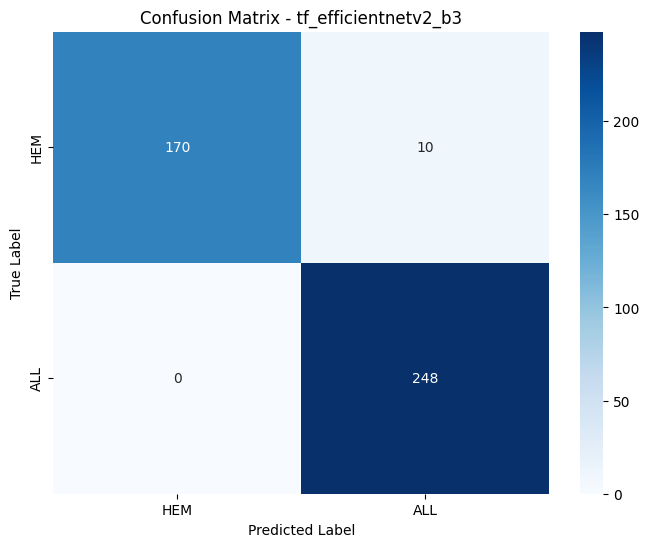

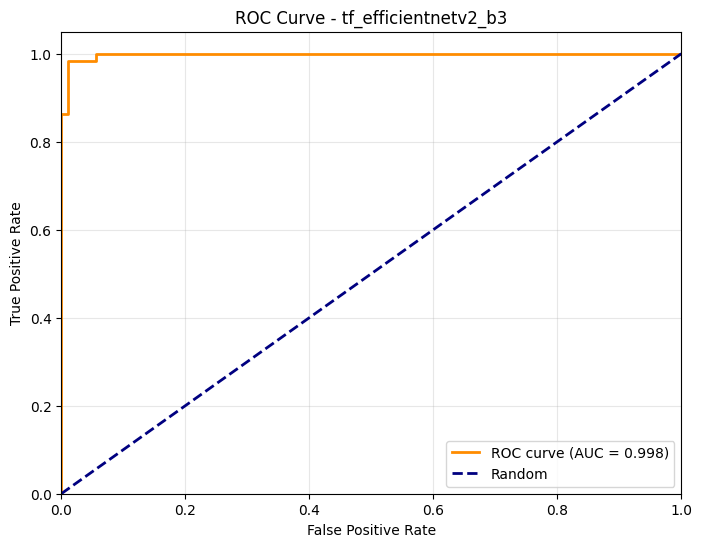


TESTANDO ENSEMBLE DE MODELOS
  HEM: 90 imagens carregadas de dataset/cnmc2019_splits/images/test/HEM
  HEM: 90 imagens carregadas de dataset/cnmc2019_splits/images/test/hem
  ALL: 124 imagens carregadas de dataset/cnmc2019_splits/images/test/ALL
  ALL: 124 imagens carregadas de dataset/cnmc2019_splits/images/test/all

Dataset de teste carregado com sucesso:
  Total de imagens: 428
  Distribuição de classes:
    ALL (classe 1): 248
    HEM (classe 0): 180

Carregando tf_efficientnetv2_b3...
✅ Modelo tf_efficientnetv2_b3 carregado - Best F1: 0.9727
  ✓ SEBlock carregado corretamente


Predicting: 100%|██████████| 27/27 [00:03<00:00,  8.27it/s]



✅ Ensemble com 1 modelos

--- Ensemble por Votação ---

MÉTRICAS - Ensemble (Voting)
Accuracy:  0.9766
Precision: 0.9775
Recall:    0.9766
F1-Score:  0.9765

Métricas por Classe:
  HEM (0) - Precision: 1.0000, Recall: 0.9444, F1: 0.9714
  ALL (1) - Precision: 0.9612, Recall: 1.0000, F1: 0.9802

Relatório de Classificação:
              precision    recall  f1-score   support

         HEM       1.00      0.94      0.97       180
         ALL       0.96      1.00      0.98       248

    accuracy                           0.98       428
   macro avg       0.98      0.97      0.98       428
weighted avg       0.98      0.98      0.98       428


--- Ensemble por Média de Probabilidades ---

MÉTRICAS - Ensemble (Average)
Accuracy:  0.9766
Precision: 0.9775
Recall:    0.9766
F1-Score:  0.9765

Métricas por Classe:
  HEM (0) - Precision: 1.0000, Recall: 0.9444, F1: 0.9714
  ALL (1) - Precision: 0.9612, Recall: 1.0000, F1: 0.9802
AUC-ROC:   0.9978

Relatório de Classificação:
              

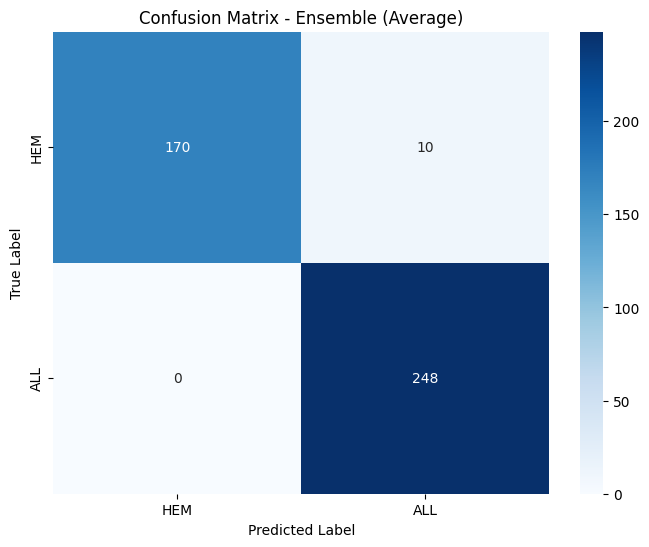

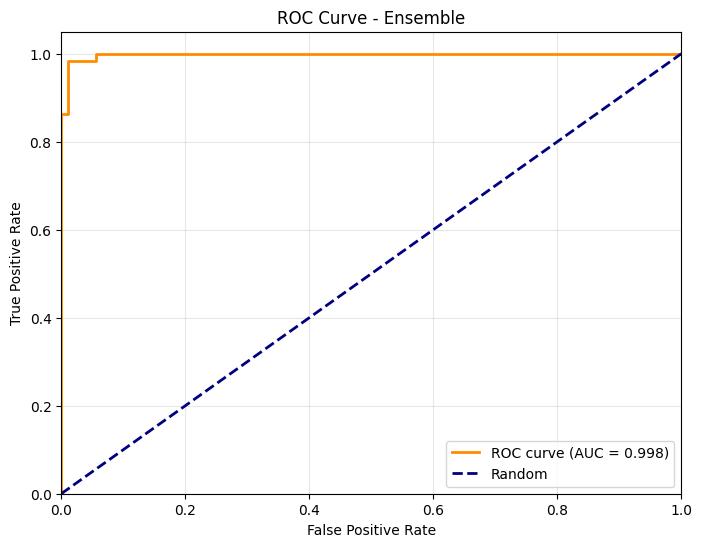


ANÁLISE DE ERROS
Total de erros: 10 / 428 (2.34%)

Erros por classe real:
  HEM incorretamente classificado como ALL: 10
  ALL incorretamente classificado como HEM: 0

Casos com baixa confiança (<70%): 8 (1.87%)


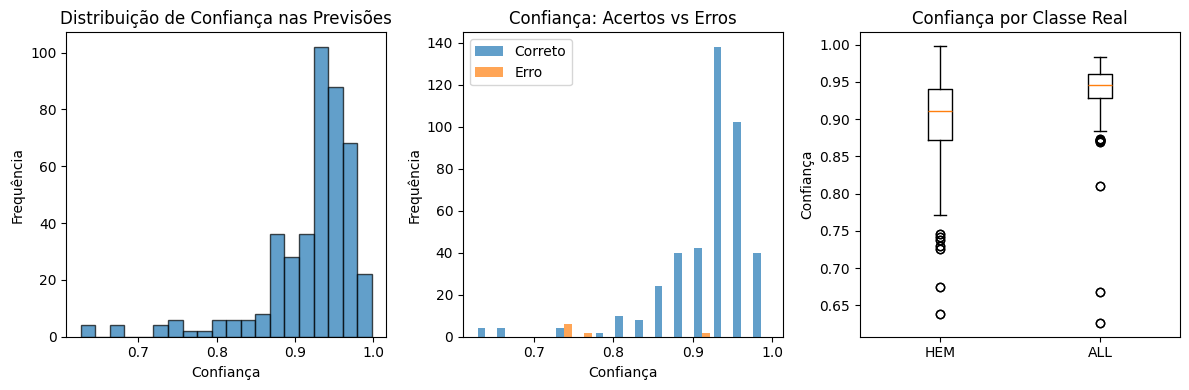


Pacientes com mais erros:
Patient_ID
h3    8
H4    2
dtype: int64

RESUMO FINAL DE RESULTADOS

Modelos Individuais:
  tf_efficientnetv2_b3: F1=0.9765, ACC=0.9766

Ensemble:
  Voting: F1=0.9765, ACC=0.9766
  Average: F1=0.9765, ACC=0.9766

✅ Resultados salvos em: test_results/


In [16]:
# Célula 13: Função auxiliar para testar com uma única imagem
def predict_single_image(image_path, model_name=None):
    """
    Faz previsão para uma única imagem
    
    Args:
        image_path: Caminho para a imagem
        model_name: Nome do modelo a usar (se None, usa ensemble)
    
    Returns:
        Dicionário com a predição e probabilidades
    """
    # Transformações
    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Carregar e preparar imagem
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(DEVICE)
    except Exception as e:
        print(f"Erro ao carregar imagem: {e}")
        return None
    
    if model_name:
        # Usar modelo específico
        model_filename = f'{model_name.replace("/", "_")}_best.pt'
        checkpoint_path = os.path.join(SAVE_DIR, model_filename)
        
        model = load_trained_model(model_name, checkpoint_path)
        if model is None:
            return None
        
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
            pred = np.argmax(probs)
        
        result = {
            'image_path': image_path,
            'model_used': model_name,
            'prediction': 'ALL' if pred == 1 else 'HEM',
            'prediction_class': pred,
            'probability_HEM': probs[0],
            'probability_ALL': probs[1],
            'confidence': max(probs)
        }
    else:
        # Usar ensemble
        all_probs = []
        models_used = []
        
        for model_name in CNN_MODELS:
            model_filename = f'{model_name.replace("/", "_")}_best.pt'
            checkpoint_path = os.path.join(SAVE_DIR, model_filename)
            
            if os.path.exists(checkpoint_path):
                model = load_trained_model(model_name, checkpoint_path)
                if model is not None:
                    model.eval()
                    with torch.no_grad():
                        outputs = model(image_tensor)
                        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
                        all_probs.append(probs)
                        models_used.append(model_name)
                    del model
                    torch.cuda.empty_cache()
        
        if len(all_probs) == 0:
            print("Nenhum modelo encontrado para ensemble")
            return None
        
        # Média das probabilidades
        avg_probs = np.mean(all_probs, axis=0)
        pred = np.argmax(avg_probs)
        
        result = {
            'image_path': image_path,
            'model_used': f'Ensemble ({len(models_used)} models)',
            'prediction': 'ALL' if pred == 1 else 'HEM',
            'prediction_class': pred,
            'probability_HEM': avg_probs[0],
            'probability_ALL': avg_probs[1],
            'confidence': max(avg_probs),
            'models_in_ensemble': models_used
        }
    
    # Exibir resultado
    print("\n" + "="*50)
    print("RESULTADO DA PREDIÇÃO")
    print("="*50)
    print(f"Imagem: {image_path}")
    print(f"Modelo: {result['model_used']}")
    print(f"Predição: {result['prediction']}")
    print(f"Probabilidades:")
    print(f"  HEM: {result['probability_HEM']:.4f}")
    print(f"  ALL: {result['probability_ALL']:.4f}")
    print(f"Confiança: {result['confidence']:.4f}")
    
    return result

# Exemplo de uso principal
if __name__ == "__main__":
    # Opção 1: Testar com pasta de imagens
    # Certifique-se de que a estrutura seja:
    # test_images_dir/
    #   ├── ALL/
    #   │   ├── imagem1.jpg
    #   │   ├── imagem2.jpg
    #   │   └── ...
    #   └── HEM/
    #       ├── imagem3.jpg
    #       ├── imagem4.jpg
    #       └── ...
    
    # Execute o pipeline completo
    results = main(test_images_dir='dataset/cnmc2019_splits/images/test')
